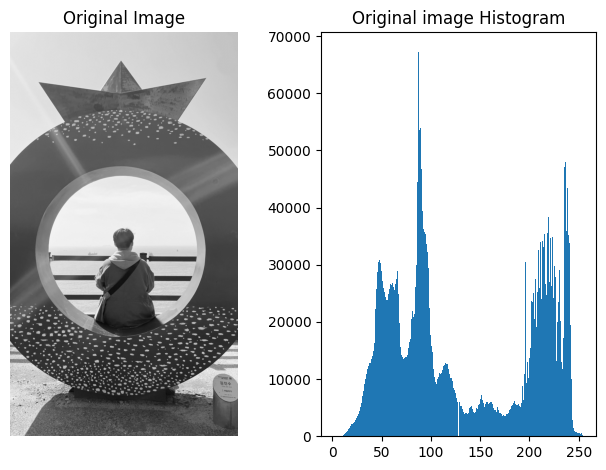

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import cv2

def mse(img1, img2):
    return np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)

original_img = Image.open("original_image.png").convert("L")

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.axis('off')
plt.imshow(original_img, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Original image Histogram")
plt.hist(np.array(original_img).flatten(), bins=256)

plt.tight_layout()
plt.show()

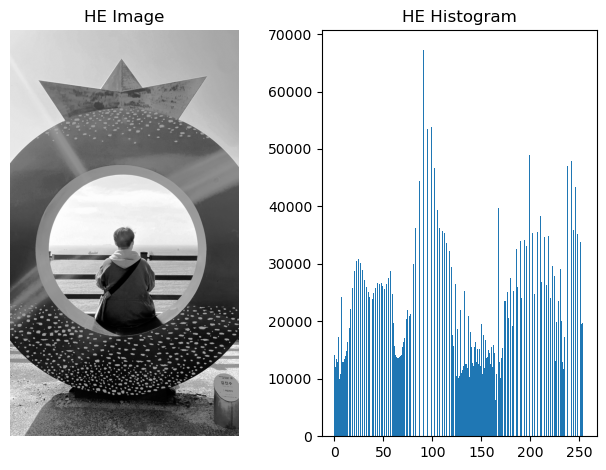

In [31]:
def histogram_equalization(img):
    img = np.array(img)
    hist = np.zeros(256)

    for pixel in img.flatten():
        hist[pixel] += 1

    pdf = hist / img.size
    cdf = np.cumsum(pdf)
    mapping = np.floor(255 * cdf).astype(np.uint8)
    equalized_img = mapping[img]

    return equalized_img

he_image = histogram_equalization(original_img)

plt.subplot(1, 2, 1)
plt.title("HE Image")
plt.axis('off')
plt.imshow(he_image, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("HE Histogram")
plt.hist(he_image.flatten(), bins=256)

plt.tight_layout()
plt.show()

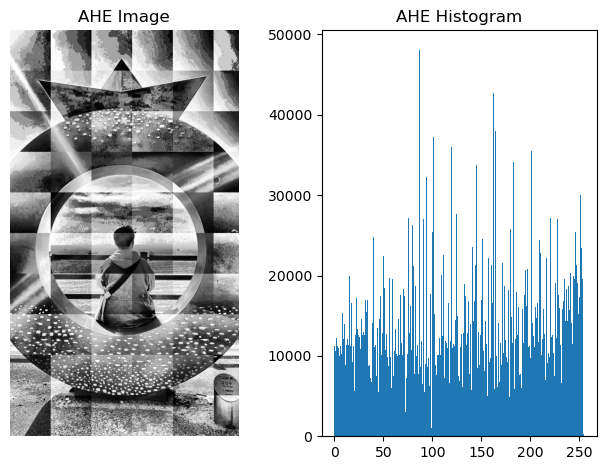

In [32]:
def ahe(img, tile_size):
    img = np.array(img)
    h, w = img.shape
    output = np.zeros_like(img)
    for y in range(0, h, tile_size):
        for x in range(0, w, tile_size):
            tile = img[y:y+tile_size, x:x+tile_size]
            n = tile.shape[0] * tile.shape[1]
            if n == 0:
                continue
            hist = np.zeros(256)
            for px in tile.flatten():
                hist[px] += 1
            cdf = np.cumsum(hist / n)
            output[y:y+tile_size, x:x+tile_size] = np.floor(255 * cdf).astype(np.uint8)[tile]
    return output
 
ahe_image = ahe(original_img, 256)
plt.subplot(1, 2, 1)
plt.title("AHE Image")
plt.axis('off')
plt.imshow(ahe_image, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("AHE Histogram")
plt.hist(ahe_image.flatten(), bins=256)

plt.tight_layout()
plt.show()

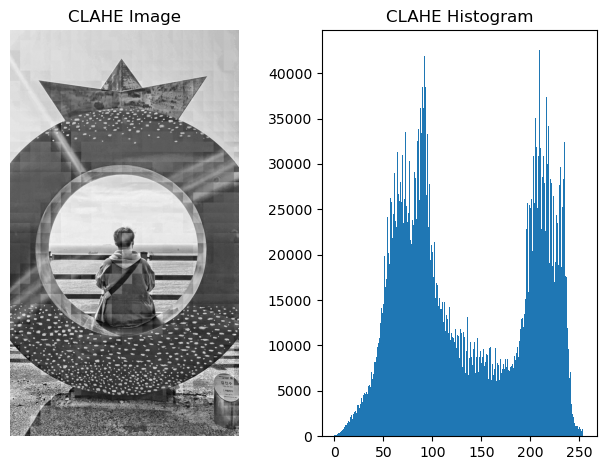

In [33]:
def clahe(img, tile_size=64, clip_limit=40.0):
    img = np.array(img)
    h, w = img.shape
    output = np.zeros_like(img)

    for y in range(0, h, tile_size):
        for x in range(0, w, tile_size):

            tile = img[y:y+tile_size, x:x+tile_size]

            hist = np.zeros(256)
            for pixel in tile.flatten():
                hist[pixel] += 1

            # clip
            excess = 0
            for i in range(256):
                if hist[i] > clip_limit:
                    excess += hist[i] - clip_limit
                    hist[i] = clip_limit

            # redistribute
            hist += excess // 256

            pdf = hist / hist.sum()
            cdf = np.cumsum(pdf)

            mapping = np.floor(255 * cdf).astype(np.uint8)

            output[y:y+tile_size, x:x+tile_size] = mapping[tile]

    return output

clahe_image = clahe(original_img)

plt.subplot(1, 2, 1)
plt.title("CLAHE Image")
plt.axis('off')
plt.imshow(clahe_image, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("CLAHE Histogram")
plt.hist(clahe_image.flatten(), bins=256)

plt.tight_layout()
plt.show()

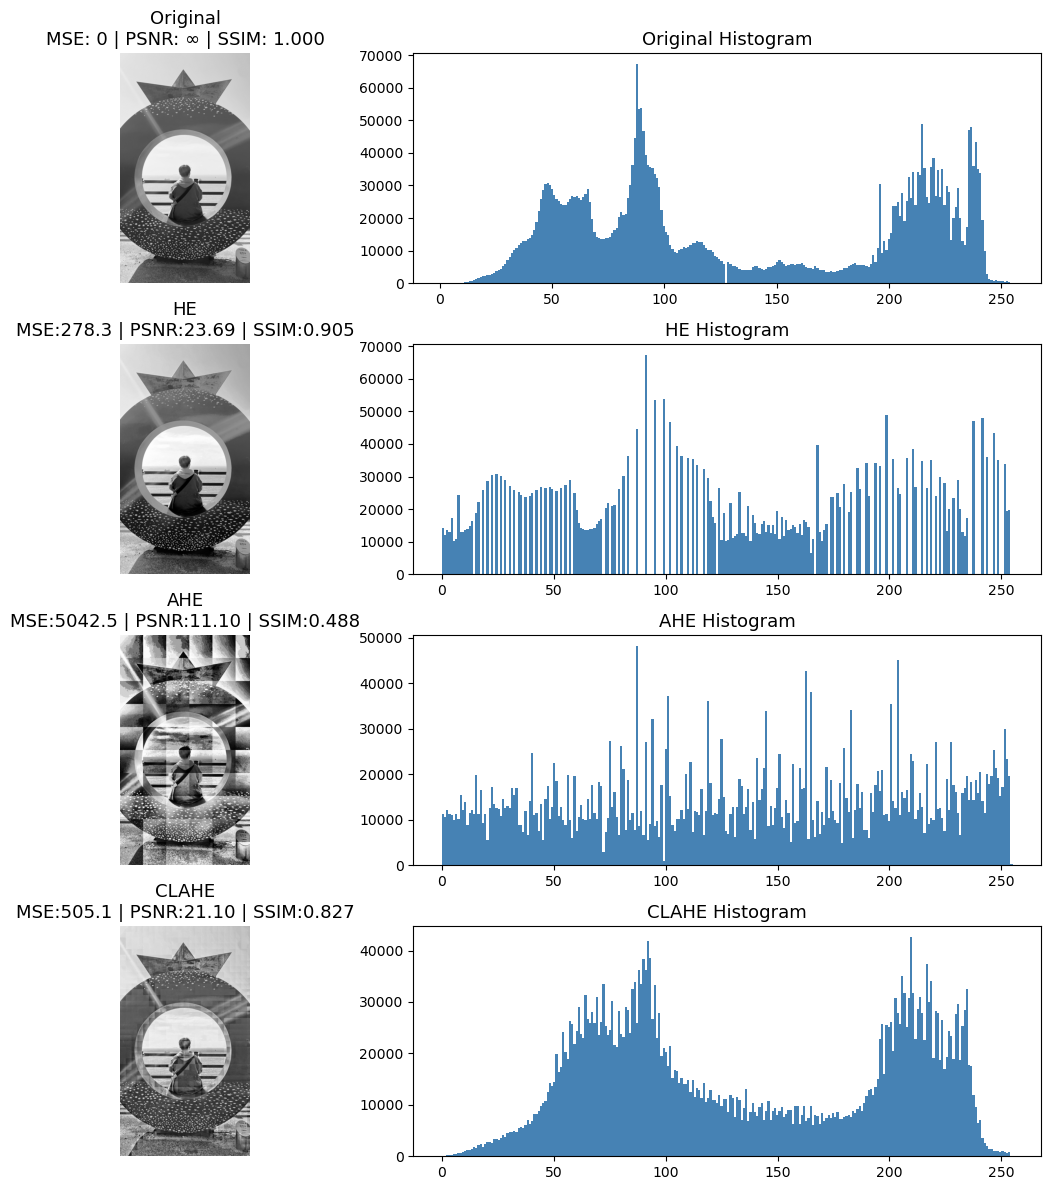

In [35]:
names = ["Original", "HE", "AHE", "CLAHE"]
imgs  = [original_img, he_image, ahe_image, clahe_image]

imgs = [np.array(img) for img in imgs]

fig, axes = plt.subplots(4, 2, figsize=(12, 12))

for row, (name, img) in enumerate(zip(names, imgs)):
    # 왼쪽: 이미지
    if name == "Original":
        title = f"{name}\nMSE: 0 | PSNR: ∞ | SSIM: 1.000"
    else:
        orig = imgs[0]
        m = mse(orig, img)
        p = peak_signal_noise_ratio(orig, img, data_range=255)
        s = structural_similarity(orig, img, data_range=255)
        title = f"{name}\nMSE:{m:.1f} | PSNR:{p:.2f} | SSIM:{s:.3f}"

    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].axis('off')
    axes[row, 0].set_title(title, fontsize=13)

    # 오른쪽: 히스토그램 (파란색)
    axes[row, 1].hist(img.flatten(), bins=256, color='steelblue')
    axes[row, 1].set_title(f"{name} Histogram", fontsize=13)

plt.tight_layout()
plt.show()

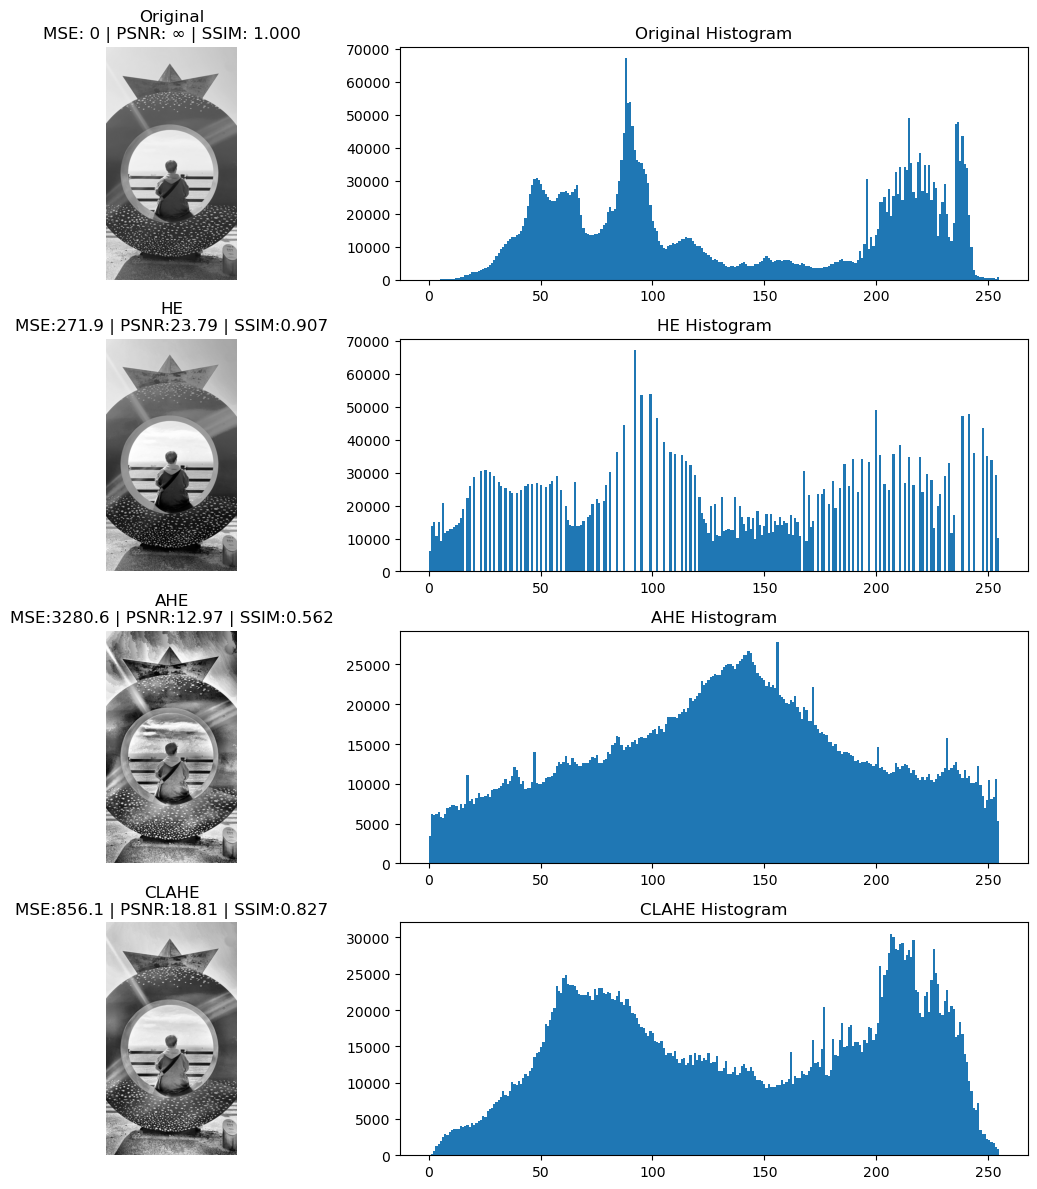

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

img = cv2.imread("original_image.png", cv2.IMREAD_GRAYSCALE)

he = cv2.equalizeHist(img)

ahe = cv2.createCLAHE(clipLimit=255.0, tileGridSize=(8,8))
ahe_img = ahe.apply(img)

clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8))
clahe_img = clahe.apply(img)

# =========================
# 평가지표
# =========================
def mse(img1, img2):
    return np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)

def get_metrics(orig, target):
    m = mse(orig, target)
    p = peak_signal_noise_ratio(orig, target, data_range=255)
    s = structural_similarity(orig, target, data_range=255)
    return m, p, s

names = ["Original", "HE", "AHE", "CLAHE"]
imgs  = [img, he, ahe_img, clahe_img]

plt.figure(figsize=(12, 12))

for i, (name, image) in enumerate(zip(names, imgs)):
    # 지표 타이틀
    if name == "Original":
        title = f"{name}\nMSE: 0 | PSNR: ∞ | SSIM: 1.000"
    else:
        m, p, s = get_metrics(img, image)
        title = f"{name}\nMSE:{m:.1f} | PSNR:{p:.2f} | SSIM:{s:.3f}"

    # 이미지
    plt.subplot(4, 2, i*2 + 1)
    plt.title(title)
    plt.imshow(image, cmap='gray')
    plt.axis('off')

    # 히스토그램
    plt.subplot(4, 2, i*2 + 2)
    plt.title(f"{name} Histogram")
    plt.hist(image.flatten(), bins=256)

plt.tight_layout()
plt.show()

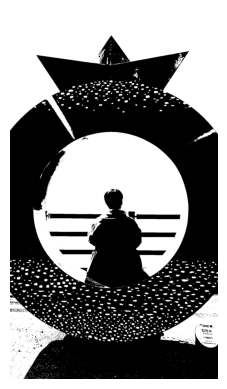

In [28]:
def binarization(img, threshold=128):
    img = np.array(img)
    
    binary_img = np.zeros_like(img, dtype=np.uint8)
    for i, pixel in enumerate(img.flatten()):
        binary_img.flat[i] = 255 if pixel >= threshold else 0

    return binary_img

binary_image = binarization(original_img, threshold=128)

plt.axis('off')
plt.imshow(binary_image, cmap='gray')
plt.show()

Otsu threshold: 144


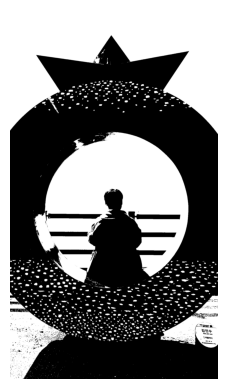

In [29]:
def binarization_otsu(img):
    img = np.array(img)
    
    hist = np.zeros(256)
    for pixel in img.flatten():
        hist[pixel] += 1
    
    pdf = hist / img.size
    
    # 분산(variance)이 최대가 되는 threshold 탐색 
    best_threshold = 0
    max_variance = 0
    
    for t in range(256):
        w0 = np.sum(pdf[:t+1])
        w1 = np.sum(pdf[t+1:])
        if w0 == 0 or w1 == 0:
            continue
        mu0 = np.sum(np.arange(t+1) * pdf[:t+1]) / w0
        mu1 = np.sum(np.arange(t+1, 256) * pdf[t+1:]) / w1
        variance = w0 * w1 * (mu0 - mu1) ** 2
        if variance > max_variance:
            max_variance = variance
            best_threshold = t
    
    binary_img = np.where(img >= best_threshold, 255, 0).astype(np.uint8)
    print(f"Otsu threshold: {best_threshold}")
    return binary_img

binary_image = binarization_otsu(original_img)

plt.axis('off')
plt.imshow(binary_image, cmap='gray')
plt.show()